In [18]:
# Set working directory
getwd()
setwd('/home/user/capstone/irs_eds_capstone/data/raw_data/Feeding_America/CSV_files')
getwd()

[1] "/home/user/capstone/irs_eds_capstone/data/raw_data/Feeding_America/CSV_files"

[1] "/home/user/capstone/irs_eds_capstone/data/raw_data/Feeding_America/CSV_files"

In [4]:
# Load in libraries for data cleaning and visualization
library(dplyr)
library(car)
library(GGally)
library(ggplot2)
library(stringr)
library(tidyverse)
library(corrplot)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:dplyr’:

    recode




Loading required package: ggplot2



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ car::recode()   masks dplyr::recode()
✖ purrr::some()   masks car::some()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


corrplot 0.95 loaded



In [19]:
# Read in county-level data file
mmg_county <- read.csv('MMG2025_2019-2023_Data_To_Share.xlsx_County.csv', header = TRUE)

# Explore the data file
dim(mmg_county)
names(mmg_county)
glimpse(mmg_county)
summary(mmg_county)
str(mmg_county)
head(mmg_county)
tail(mmg_county)

[1] 15716    24

[1] "FIPS"                                                       
 [2] "State"                                                      
 [3] "County..State"                                              
 [4] "Year"                                                       
 [5] "Overall.Food.Insecurity.Rate"                               
 [6] "X..of.Food.Insecure.Persons.Overall"                        
 [7] "Food.Insecurity.Rate.among.Black.Persons..all.ethnicities." 
 [8] "Food.Insecurity.Rate.among.Hispanic.Persons..any.race."     
 [9] "Food.Insecurity.Rate.among.White..non.Hispanic.Persons"     
[10] "SNAP.Threshold"                                             
[11] "X..FI...SNAP.Threshold"                                     
[12] "X..FI...SNAP.Threshold.1"                                   
[13] "Child.Food.Insecurity.Rate"                                 
[14] "X..of.Food.Insecure.Children"                               
[15] "X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL"
[16] "X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL"
[17] "Cost.Per.Meal"                                              
[18] "Weighted.weekly...needed.by.FI"                             
[19] "Weighted.Annual.Food.Budget.Shortfall"                      
[20] "Rural.Urban.Continuum.Code..2013."                          
[21] "Rural.Urban.Continuum.Code..2023."                          
[22] "Census.Region"                                              
[23] "Census.Division"                                            
[24] "FNS.Region"

Rows: 15,716
Columns: 24
$ FIPS                                                        <int> 1001, 1001…
$ State                                                       <chr> "AL", "AL"…
$ County..State                                               <chr> "Autauga C…
$ Year                                                        <int> 2019, 2020…
$ Overall.Food.Insecurity.Rate                                <chr> "15.7%", "…
$ X..of.Food.Insecure.Persons.Overall                         <chr> "8,670", "…
$ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.  <chr> "26%", "25…
$ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.      <chr> "", "", ""…
$ Food.Insecurity.Rate.among.White..non.Hispanic.Persons      <chr> "12%", "9%…
$ SNAP.Threshold                                              <chr> "130%", "1…
$ X..FI...SNAP.Threshold                                      <chr> "49%", "48…
$ X..FI...SNAP.Threshold.1                                    <chr> "51%", "52…
$ Child.Food.In

      FIPS          State           County..State           Year     
 Min.   : 1001   Length:15716       Length:15716       Min.   :2019  
 1st Qu.:18175   Class :character   Class :character   1st Qu.:2020  
 Median :29175   Mode  :character   Mode  :character   Median :2021  
 Mean   :30374                                         Mean   :2021  
 3rd Qu.:45081                                         3rd Qu.:2022  
 Max.   :56045                                         Max.   :2023  
                                                                     
 Overall.Food.Insecurity.Rate X..of.Food.Insecure.Persons.Overall
 Length:15716                 Length:15716                       
 Class :character             Class :character                   
 Mode  :character             Mode  :character                   
                                                                 
                                                                 
                                            

'data.frame':	15716 obs. of  24 variables:
 $ FIPS                                                       : int  1001 1001 1001 1001 1001 1003 1003 1003 1003 1003 ...
 $ State                                                      : chr  "AL" "AL" "AL" "AL" ...
 $ County..State                                              : chr  "Autauga County, Alabama" "Autauga County, Alabama" "Autauga County, Alabama" "Autauga County, Alabama" ...
 $ Year                                                       : int  2019 2020 2021 2022 2023 2019 2020 2021 2022 2023 ...
 $ Overall.Food.Insecurity.Rate                               : chr  "15.7%" "14.5%" "13.3%" "15.1%" ...
 $ X..of.Food.Insecure.Persons.Overall                        : chr  "8,670" "8,070" "7,770" "8,860" ...
 $ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities. : chr  "26%" "25%" "23%" "23%" ...
 $ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.     : chr  "" "" "" "" ...
 $ Food.Insecurity.Rate.among.White..non.Hispanic

,FIPS,State,County..State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold,⋯,X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL,X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Rural.Urban.Continuum.Code..2013.,Rural.Urban.Continuum.Code..2023.,Census.Region,Census.Division,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,1001,AL,"Autauga County, Alabama",2019,15.7%,"8,670",26%,,12%,130%,⋯,69%,31%,$3.00,$16.88,"$4,439,000",2,NA,South,East South Central,Southeast
2,1001,AL,"Autauga County, Alabama",2020,14.5%,"8,070",25%,,9%,130%,⋯,71%,29%,$3.22,$17.09,"$4,184,000",2,NA,South,East South Central,Southeast
3,1001,AL,"Autauga County, Alabama",2021,13.3%,"7,770",23%,,9%,130%,⋯,68%,32%,$3.60,$20.99,"$4,947,000",2,NA,South,East South Central,Southeast
4,1001,AL,"Autauga County, Alabama",2022,15.1%,"8,860",23%,,11%,130%,⋯,68%,32%,$4.01,$24.86,"$6,680,000",2,2,South,East South Central,Southeast
5,1001,AL,"Autauga County, Alabama",2023,15.1%,"8,970",24%,,12%,130%,⋯,66%,34%,$3.64,$22.72,"$6,183,000",2,2,South,East South Central,Southeast
6,1003,AL,"Baldwin County, Alabama",2019,13.4%,"28,590",26%,10%,11%,130%,⋯,79%,21%,$3.66,$20.63,"$17,895,000",3,NA,South,East South Central,Southeast


,FIPS,State,County..State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold,⋯,X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL,X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Rural.Urban.Continuum.Code..2013.,Rural.Urban.Continuum.Code..2023.,Census.Region,Census.Division,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
15711,56043,WY,"Washakie County, Wyoming",2023,14.7%,"1,130",,21%,12%,130%,⋯,92%,8%,$3.74,$23.36,"$801,000",7,9,West,Mountain,Mountain Plains
15712,56045,WY,"Weston County, Wyoming",2019,12.2%,860,,,12%,130%,⋯,62%,38%,$3.21,$18.07,"$471,000",7,NA,West,Mountain,Mountain Plains
15713,56045,WY,"Weston County, Wyoming",2020,11.0%,760,,,10%,130%,⋯,50%,50%,$3.37,$17.90,"$413,000",7,NA,West,Mountain,Mountain Plains
15714,56045,WY,"Weston County, Wyoming",2021,10.2%,710,,,10%,130%,⋯,49%,51%,$3.73,$21.74,"$468,000",7,NA,West,Mountain,Mountain Plains
15715,56045,WY,"Weston County, Wyoming",2022,13.6%,940,,,12%,130%,⋯,47%,53%,$4.13,$25.57,"$729,000",7,9,West,Mountain,Mountain Plains
15716,56045,WY,"Weston County, Wyoming",2023,13.9%,950,,,12%,130%,⋯,41%,59%,$3.72,$23.21,"$669,000",7,9,West,Mountain,Mountain Plains


In [20]:
# Read in state-level data file
mmg_state <- read.csv('MMG2025_2019-2023_Data_To_Share.xlsx_State.csv', header = TRUE)

# Explore the data file
dim(mmg_state)
names(mmg_state)
glimpse(mmg_state)
summary(mmg_state)
str(mmg_state)
head(mmg_state)
tail(mmg_state)

[1] 255  26

[1] "FIPS"                                                      
 [2] "State.Name"                                                
 [3] "State"                                                     
 [4] "Year"                                                      
 [5] "Overall.Food.Insecurity.Rate"                              
 [6] "X..of.Food.Insecure.Persons.Overall"                       
 [7] "Food.Insecurity.Rate.among.Black.Persons..all.ethnicities."
 [8] "Food.Insecurity.Rate.among.Hispanic.Persons..any.race."    
 [9] "Food.Insecurity.Rate.among.White..non.Hispanic.Persons"    
[10] "SNAP.Threshold.in.State"                                   
[11] "X..FI...SNAP.Threshold"                                    
[12] "X..FI...SNAP.Threshold.1"                                  
[13] "Child.Food.Insecurity.Rate"                                
[14] "X..of.Food.Insecure.Children"                              
[15] "X..food.insecure.Children.in.HH.w.HH.Incomes.Below.185.FPL"
[16] "X..food.insecure.Children.in.HH.w.HH.Incomes.Above.185.FPL"
[17] "Senior.Food.Insecurity.Rate"                               
[18] "X..of.Food.Insecure.Seniors"                               
[19] "Older.Adult.Food.Insecurity.Rate"                          
[20] "X..of.Food.Insecure.Older.Adults"                          
[21] "Cost.Per.Meal"                                             
[22] "Weighted.weekly...needed.by.FI"                            
[23] "Weighted.Annual.Food.Budget.Shortfall"                     
[24] "Census.Division"                                           
[25] "Census.Region"                                             
[26] "FNS.Region"

Rows: 255
Columns: 26
$ FIPS                                                       <int> 1, 1, 1, 1,…
$ State.Name                                                 <chr> "Alabama", …
$ State                                                      <chr> "AL", "AL",…
$ Year                                                       <int> 2019, 2020,…
$ Overall.Food.Insecurity.Rate                               <chr> "16.1%", "1…
$ X..of.Food.Insecure.Persons.Overall                        <chr> "788,250", …
$ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities. <chr> "27%", "27%…
$ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.     <chr> "13%", "14%…
$ Food.Insecurity.Rate.among.White..non.Hispanic.Persons     <chr> "12%", "10%…
$ SNAP.Threshold.in.State                                    <chr> "130%", "13…
$ X..FI...SNAP.Threshold                                     <chr> "50%", "53%…
$ X..FI...SNAP.Threshold.1                                   <chr> "50%", "48%…
$ Child.Food.Insec

      FIPS        State.Name           State                Year     
 Min.   : 1.00   Length:255         Length:255         Min.   :2019  
 1st Qu.:16.00   Class :character   Class :character   1st Qu.:2020  
 Median :29.00   Mode  :character   Mode  :character   Median :2021  
 Mean   :28.96                                         Mean   :2021  
 3rd Qu.:42.00                                         3rd Qu.:2022  
 Max.   :56.00                                         Max.   :2023  
 Overall.Food.Insecurity.Rate X..of.Food.Insecure.Persons.Overall
 Length:255                   Length:255                         
 Class :character             Class :character                   
 Mode  :character             Mode  :character                   
                                                                 
                                                                 
                                                                 
 Food.Insecurity.Rate.among.Black.Persons..all.e

'data.frame':	255 obs. of  26 variables:
 $ FIPS                                                      : int  1 1 1 1 1 2 2 2 2 2 ...
 $ State.Name                                                : chr  "Alabama" "Alabama" "Alabama" "Alabama" ...
 $ State                                                     : chr  "AL" "AL" "AL" "AL" ...
 $ Year                                                      : int  2019 2020 2021 2022 2023 2019 2020 2021 2022 2023 ...
 $ Overall.Food.Insecurity.Rate                              : chr  "16.1%" "14.5%" "14.8%" "17.4%" ...
 $ X..of.Food.Insecure.Persons.Overall                       : chr  "788,250" "711,370" "746,550" "884,270" ...
 $ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.: chr  "27%" "27%" "26%" "31%" ...
 $ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.    : chr  "13%" "14%" "12%" "18%" ...
 $ Food.Insecurity.Rate.among.White..non.Hispanic.Persons    : chr  "12%" "10%" "10%" "12%" ...
 $ SNAP.Threshold.in.State           

,FIPS,State.Name,State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold.in.State,⋯,Senior.Food.Insecurity.Rate,X..of.Food.Insecure.Seniors,Older.Adult.Food.Insecurity.Rate,X..of.Food.Insecure.Older.Adults,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Census.Division,Census.Region,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,Alabama,AL,2019,16.1%,"788,250",27%,13%,12%,130%,⋯,9.4%,"105,776",15.6%,"105,533",$3.01,$16.96,"$405,611,000",East South Central,South,Southeast
2,1,Alabama,AL,2020,14.5%,"711,370",27%,14%,10%,130%,⋯,9.0%,"104,269",14.2%,"97,677",$3.13,$16.62,"$358,615,000",East South Central,South,Southeast
3,1,Alabama,AL,2021,14.8%,"746,550",26%,12%,10%,130%,⋯,8.9%,"103,567",14.4%,"100,289",$3.50,$20.36,"$461,137,000",East South Central,South,Southeast
4,1,Alabama,AL,2022,17.4%,"884,270",31%,18%,12%,130%,⋯,9.2%,"109,300",13.4%,"87,500",$3.91,$24.24,"$650,301,000",East South Central,South,Southeast
5,1,Alabama,AL,2023,17.5%,"896,510",31%,19%,13%,130%,⋯,8.1%,"103,465",10.8%,"62,405",$3.50,$21.84,"$594,027,000",East South Central,South,Southeast
6,2,Alaska,AK,2019,11.9%,"86,970",18%,14%,9%,130%,⋯,6.7%,"8,609",10.7%,"9,576",$3.63,$20.43,"$53,905,000",Pacific,West,Western


,FIPS,State.Name,State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold.in.State,⋯,Senior.Food.Insecurity.Rate,X..of.Food.Insecure.Seniors,Older.Adult.Food.Insecurity.Rate,X..of.Food.Insecure.Older.Adults,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Census.Division,Census.Region,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
250,55,Wisconsin,WI,2023,11.8%,"694,710",32%,27%,9%,200%,⋯,6.3%,"89,360",11.3%,"93,997",$3.52,$21.99,"$463,353,000",East North Central,Midwest,Midwest
251,56,Wyoming,WY,2019,11.7%,"67,750",,14%,12%,130%,⋯,5.7%,"7,685",9.4%,"6,671",$3.12,$17.60,"$36,177,000",Mountain,West,Mountain Plains
252,56,Wyoming,WY,2020,10.2%,"59,570",,14%,10%,130%,⋯,8.2%,"11,592",8.7%,"5,868",$3.13,$16.64,"$30,065,000",Mountain,West,Mountain Plains
253,56,Wyoming,WY,2021,10.6%,"61,200",,11%,10%,130%,⋯,7.3%,"10,890",7.6%,"4,923",$3.50,$20.37,"$37,813,000",Mountain,West,Mountain Plains
254,56,Wyoming,WY,2022,14.4%,"83,780",,18%,12%,130%,⋯,7.6%,"11,400",10.5%,"7,100",$3.90,$24.17,"$61,418,000",Mountain,West,Mountain Plains
255,56,Wyoming,WY,2023,15.4%,"90,020",,20%,13%,130%,⋯,9.4%,"14,485",14.3%,"9,156",$3.51,$21.93,"$59,883,000",Mountain,West,Mountain Plains


In [21]:
# Read in congressional district-level data file
mmg_cd <- read.csv('MMG2025_2019-2023_Data_To_Share_Congressional District.csv', header = TRUE)

# Explore the data file
dim(mmg_cd)
names(mmg_cd)
glimpse(mmg_cd)
summary(mmg_cd)
str(mmg_cd)
head(mmg_cd)
tail(mmg_cd)

[1] 2180   19

[1] "FIPS"                                                       
 [2] "State"                                                      
 [3] "District"                                                   
 [4] "Year"                                                       
 [5] "Overall.Food.Insecurity.Rate"                               
 [6] "X..of.Food.Insecure.Persons.Overall"                        
 [7] "Food.Insecurity.Rate.among.Black.Persons..all.ethnicities." 
 [8] "Food.Insecurity.Rate.among.Hispanic.Persons..any.race."     
 [9] "Food.Insecurity.Rate.among.White..non.Hispanic.Persons"     
[10] "SNAP.Threshold"                                             
[11] "X..FI...SNAP.Threshold"                                     
[12] "X..FI...SNAP.Threshold.1"                                   
[13] "Child.Food.Insecurity.Rate"                                 
[14] "X..of.Food.Insecure.Children"                               
[15] "X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL"
[16] "X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL"
[17] "Census.Region"                                              
[18] "Census.Division"                                            
[19] "FNS.Region"

Rows: 2,180
Columns: 19
$ FIPS                                                        <int> 101, 101, …
$ State                                                       <chr> "AL", "AL"…
$ District                                                    <chr> "Congressi…
$ Year                                                        <int> 2019, 2020…
$ Overall.Food.Insecurity.Rate                                <chr> "16.1%", "…
$ X..of.Food.Insecure.Persons.Overall                         <chr> "115,250",…
$ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.  <chr> "28%", "29…
$ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.      <chr> "12%", "12…
$ Food.Insecurity.Rate.among.White..non.Hispanic.Persons      <chr> "12%", "9%…
$ SNAP.Threshold                                              <chr> "130%", "1…
$ X..FI...SNAP.Threshold                                      <chr> "50%", "51…
$ X..FI...SNAP.Threshold.1                                    <chr> "50%", "49…
$ Child.Food.Ins

      FIPS         State             District              Year     
 Min.   : 101   Length:2180        Length:2180        Min.   :2019  
 1st Qu.:1222   Class :character   Class :character   1st Qu.:2020  
 Median :2706   Mode  :character   Mode  :character   Median :2021  
 Mean   :2773                                         Mean   :2021  
 3rd Qu.:4202                                         3rd Qu.:2022  
 Max.   :5600                                         Max.   :2023  
 Overall.Food.Insecurity.Rate X..of.Food.Insecure.Persons.Overall
 Length:2180                  Length:2180                        
 Class :character             Class :character                   
 Mode  :character             Mode  :character                   
                                                                 
                                                                 
                                                                 
 Food.Insecurity.Rate.among.Black.Persons..all.ethnicit

'data.frame':	2180 obs. of  19 variables:
 $ FIPS                                                       : int  101 101 101 101 101 102 102 102 102 102 ...
 $ State                                                      : chr  "AL" "AL" "AL" "AL" ...
 $ District                                                   : chr  "Congressional District 1 (116th Congress), Alabama" "Congressional District 1, Alabama" "Congressional District 1, Alabama" "Congressional District 1 (118th Congress), Alabama" ...
 $ Year                                                       : int  2019 2020 2021 2022 2023 2019 2020 2021 2022 2023 ...
 $ Overall.Food.Insecurity.Rate                               : chr  "16.1%" "14.1%" "14.7%" "17.8%" ...
 $ X..of.Food.Insecure.Persons.Overall                        : chr  "115,250" "100,850" "108,230" "130,000" ...
 $ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities. : chr  "28%" "29%" "28%" "33%" ...
 $ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.     :

,FIPS,State,District,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold,X..FI...SNAP.Threshold,X..FI...SNAP.Threshold.1,Child.Food.Insecurity.Rate,X..of.Food.Insecure.Children,X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL,X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL,Census.Region,Census.Division,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,101,AL,"Congressional District 1 (116th Congress), Alabama",2019,16.1%,"115,250",28%,12%,12%,130%,50%,50%,21.9%,"35,290",74%,26%,South,East South Central,Southeast
2,101,AL,"Congressional District 1, Alabama",2020,14.1%,"100,850",29%,12%,9%,130%,51%,49%,19.5%,"31,670",82%,18%,South,East South Central,Southeast
3,101,AL,"Congressional District 1, Alabama",2021,14.7%,"108,230",28%,10%,10%,130%,40%,60%,18.6%,"30,560",77%,23%,South,East South Central,Southeast
4,101,AL,"Congressional District 1 (118th Congress), Alabama",2022,17.8%,"130,000",33%,18%,12%,130%,39%,61%,23.8%,"38,380",76%,24%,South,East South Central,Southeast
5,101,AL,"Congressional District 1 (118th Congress), Alabama",2023,16.3%,"119,750",33%,18%,12%,130%,45%,55%,21.8%,"35,490",80%,20%,South,East South Central,Southeast
6,102,AL,"Congressional District 2 (116th Congress), Alabama",2019,16.3%,"109,950",28%,14%,13%,130%,52%,48%,23.1%,"35,050",71%,29%,South,East South Central,Southeast


,FIPS,State,District,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold,X..FI...SNAP.Threshold,X..FI...SNAP.Threshold.1,Child.Food.Insecurity.Rate,X..of.Food.Insecure.Children,X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL,X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL,Census.Region,Census.Division,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2175,5508,WI,"Congressional District 8 (118th Congress), Wisconsin",2023,11.0%,"81,320",33%,27%,8%,200%,57%,43%,14.1%,"22,550",73%,27%,Midwest,East North Central,Midwest
2176,5600,WY,"Congressional District (at Large) (116th Congress), Wyoming",2019,11.7%,"67,750",,14%,12%,130%,41%,60%,14.6%,"19,530",58%,42%,West,Mountain,Mountain Plains
2177,5600,WY,"Congressional District (at Large), Wyoming",2020,10.2%,"59,570",,14%,10%,130%,46%,54%,12.9%,"17,390",68%,32%,West,Mountain,Mountain Plains
2178,5600,WY,"Congressional District (at Large), Wyoming",2021,10.6%,"61,200",,11%,10%,130%,35%,65%,12.2%,"16,100",65%,35%,West,Mountain,Mountain Plains
2179,5600,WY,"Congressional District (at Large) (118th Congress), Wyoming",2022,14.4%,"83,780",,18%,12%,130%,33%,67%,19.4%,"25,140",57%,43%,West,Mountain,Mountain Plains
2180,5600,WY,"Congressional District (at Large) (118th Congress), Wyoming",2023,15.4%,"90,020",,20%,14%,130%,41%,59%,21.0%,"27,230",63%,37%,West,Mountain,Mountain Plains


In [22]:
# Read in read me file
mmg_read_me <- read.csv('MMG2025_2019-2023_Data_To_Share_read_me.csv', header = FALSE)

# Explore the read me file
mmg_read_me

V1,V2,V3,V4,V5
<chr>,<chr>,<chr>,<chr>,<chr>
Dataset that combines Feeding America's Map the Meal Gap 2025: An Analysis of County and Congressional District Food Insecurity and County Food Cost in the United States in 2023,,,,
,,,,
Recommended Citations,Relevant Data,,,
"Ribar, D.C., Harris, V., Dewey, A., Dawes, S., and Engelhard, E. (2025). Map the Meal Gap: An Analysis of Local Food Insecurity and Food Costs in the United States in 2023. Feeding America National Organization.",Citation for 2023 data from Map the Meal Gap,,,
"Dewey, A., Harris, V., Hake, M., & Engelhard, E. (2024). Map the Meal Gap 2024: An Analysis of County and Congressional District Food Insecurity and County Food Cost in the United States in 2022. Feeding America.",Citation for 2022 data from Map the Meal Gap,,,
"Gundersen C., Ziliak, J. (2023). Hunger Among Adults Age 50-59 in 2021: An Annual Report. Report for Feeding America. Available from Feeding America: https://www.feedingamerica.org/research/state-senior-hunger",Citation for 2021 data about older adults age 50-59,,,
"Ziliak, J., Gundersen, C. (2023). The State of Senior Hunger in America in 2021: An Annual Report. Report for Feeding America. Available from Feeding America: https://www.feedingamerica.org/research/state-senior-hunger",Citation for 2021 data about seniors 60+,,,
"Gundersen, C., Strayer, M., Dewey, A., Hake, M., & Engelhard, E. (2023). Map the Meal Gap 2023: An Analysis of County and Congressional District Food Insecurity and County Food Cost in the United States in 2021. Feeding America.",All other 2021 data from Map the Meal Gap,,,
"Gundersen, C., Strayer, M., Dewey, A., Hake, M., & Engelhard, E. (2022). Map the Meal Gap 2022: An Analysis of County and Congressional District Food Insecurity and County Food Cost in the United States in 2020. Feeding America.",Citation for 2020 data from Map the Meal Gap.,,,


In [23]:
# Let's start by seeing which has more data, the county or congressional district level
dim(mmg_county)
dim(mmg_cd)

# There seem to be many more observations in the county dataset, so let's start working with that one.
# Let's explore the county data once more
# Explore the data file
names(mmg_county)
glimpse(mmg_county)
summary(mmg_county)
str(mmg_county)
head(mmg_county)
tail(mmg_county)

[1] 15716    24

[1] 2180   19

[1] "FIPS"                                                       
 [2] "State"                                                      
 [3] "County..State"                                              
 [4] "Year"                                                       
 [5] "Overall.Food.Insecurity.Rate"                               
 [6] "X..of.Food.Insecure.Persons.Overall"                        
 [7] "Food.Insecurity.Rate.among.Black.Persons..all.ethnicities." 
 [8] "Food.Insecurity.Rate.among.Hispanic.Persons..any.race."     
 [9] "Food.Insecurity.Rate.among.White..non.Hispanic.Persons"     
[10] "SNAP.Threshold"                                             
[11] "X..FI...SNAP.Threshold"                                     
[12] "X..FI...SNAP.Threshold.1"                                   
[13] "Child.Food.Insecurity.Rate"                                 
[14] "X..of.Food.Insecure.Children"                               
[15] "X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL"
[16] "X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL"
[17] "Cost.Per.Meal"                                              
[18] "Weighted.weekly...needed.by.FI"                             
[19] "Weighted.Annual.Food.Budget.Shortfall"                      
[20] "Rural.Urban.Continuum.Code..2013."                          
[21] "Rural.Urban.Continuum.Code..2023."                          
[22] "Census.Region"                                              
[23] "Census.Division"                                            
[24] "FNS.Region"

Rows: 15,716
Columns: 24
$ FIPS                                                        <int> 1001, 1001…
$ State                                                       <chr> "AL", "AL"…
$ County..State                                               <chr> "Autauga C…
$ Year                                                        <int> 2019, 2020…
$ Overall.Food.Insecurity.Rate                                <chr> "15.7%", "…
$ X..of.Food.Insecure.Persons.Overall                         <chr> "8,670", "…
$ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.  <chr> "26%", "25…
$ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.      <chr> "", "", ""…
$ Food.Insecurity.Rate.among.White..non.Hispanic.Persons      <chr> "12%", "9%…
$ SNAP.Threshold                                              <chr> "130%", "1…
$ X..FI...SNAP.Threshold                                      <chr> "49%", "48…
$ X..FI...SNAP.Threshold.1                                    <chr> "51%", "52…
$ Child.Food.In

      FIPS          State           County..State           Year     
 Min.   : 1001   Length:15716       Length:15716       Min.   :2019  
 1st Qu.:18175   Class :character   Class :character   1st Qu.:2020  
 Median :29175   Mode  :character   Mode  :character   Median :2021  
 Mean   :30374                                         Mean   :2021  
 3rd Qu.:45081                                         3rd Qu.:2022  
 Max.   :56045                                         Max.   :2023  
                                                                     
 Overall.Food.Insecurity.Rate X..of.Food.Insecure.Persons.Overall
 Length:15716                 Length:15716                       
 Class :character             Class :character                   
 Mode  :character             Mode  :character                   
                                                                 
                                                                 
                                            

'data.frame':	15716 obs. of  24 variables:
 $ FIPS                                                       : int  1001 1001 1001 1001 1001 1003 1003 1003 1003 1003 ...
 $ State                                                      : chr  "AL" "AL" "AL" "AL" ...
 $ County..State                                              : chr  "Autauga County, Alabama" "Autauga County, Alabama" "Autauga County, Alabama" "Autauga County, Alabama" ...
 $ Year                                                       : int  2019 2020 2021 2022 2023 2019 2020 2021 2022 2023 ...
 $ Overall.Food.Insecurity.Rate                               : chr  "15.7%" "14.5%" "13.3%" "15.1%" ...
 $ X..of.Food.Insecure.Persons.Overall                        : chr  "8,670" "8,070" "7,770" "8,860" ...
 $ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities. : chr  "26%" "25%" "23%" "23%" ...
 $ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.     : chr  "" "" "" "" ...
 $ Food.Insecurity.Rate.among.White..non.Hispanic

,FIPS,State,County..State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold,⋯,X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL,X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Rural.Urban.Continuum.Code..2013.,Rural.Urban.Continuum.Code..2023.,Census.Region,Census.Division,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,1001,AL,"Autauga County, Alabama",2019,15.7%,"8,670",26%,,12%,130%,⋯,69%,31%,$3.00,$16.88,"$4,439,000",2,NA,South,East South Central,Southeast
2,1001,AL,"Autauga County, Alabama",2020,14.5%,"8,070",25%,,9%,130%,⋯,71%,29%,$3.22,$17.09,"$4,184,000",2,NA,South,East South Central,Southeast
3,1001,AL,"Autauga County, Alabama",2021,13.3%,"7,770",23%,,9%,130%,⋯,68%,32%,$3.60,$20.99,"$4,947,000",2,NA,South,East South Central,Southeast
4,1001,AL,"Autauga County, Alabama",2022,15.1%,"8,860",23%,,11%,130%,⋯,68%,32%,$4.01,$24.86,"$6,680,000",2,2,South,East South Central,Southeast
5,1001,AL,"Autauga County, Alabama",2023,15.1%,"8,970",24%,,12%,130%,⋯,66%,34%,$3.64,$22.72,"$6,183,000",2,2,South,East South Central,Southeast
6,1003,AL,"Baldwin County, Alabama",2019,13.4%,"28,590",26%,10%,11%,130%,⋯,79%,21%,$3.66,$20.63,"$17,895,000",3,NA,South,East South Central,Southeast


,FIPS,State,County..State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold,⋯,X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL,X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Rural.Urban.Continuum.Code..2013.,Rural.Urban.Continuum.Code..2023.,Census.Region,Census.Division,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
15711,56043,WY,"Washakie County, Wyoming",2023,14.7%,"1,130",,21%,12%,130%,⋯,92%,8%,$3.74,$23.36,"$801,000",7,9,West,Mountain,Mountain Plains
15712,56045,WY,"Weston County, Wyoming",2019,12.2%,860,,,12%,130%,⋯,62%,38%,$3.21,$18.07,"$471,000",7,NA,West,Mountain,Mountain Plains
15713,56045,WY,"Weston County, Wyoming",2020,11.0%,760,,,10%,130%,⋯,50%,50%,$3.37,$17.90,"$413,000",7,NA,West,Mountain,Mountain Plains
15714,56045,WY,"Weston County, Wyoming",2021,10.2%,710,,,10%,130%,⋯,49%,51%,$3.73,$21.74,"$468,000",7,NA,West,Mountain,Mountain Plains
15715,56045,WY,"Weston County, Wyoming",2022,13.6%,940,,,12%,130%,⋯,47%,53%,$4.13,$25.57,"$729,000",7,9,West,Mountain,Mountain Plains
15716,56045,WY,"Weston County, Wyoming",2023,13.9%,950,,,12%,130%,⋯,41%,59%,$3.72,$23.21,"$669,000",7,9,West,Mountain,Mountain Plains


In [25]:
# Let's fix the column names so they follow the snake structure
mmg_county_clean <- rename(mmg_county,
                           fips =  'FIPS',
                           state_abbrev = 'State',
                           county_state = 'County..State',
                           year = 'Year',
                           FI_rate_overall = 'Overall.Food.Insecurity.Rate',
                           FI_number_total = 'X..of.Food.Insecure.Persons.Overall',
                           FI_rate_black = 'Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.',
                           FI_rate_hispanic ='Food.Insecurity.Rate.among.Hispanic.Persons..any.race.',
                           FI_rate_white = 'Food.Insecurity.Rate.among.White..non.Hispanic.Persons',
                           state_snap_threshold = 'SNAP.Threshold',
                           percent_below_snap = 'X..FI...SNAP.Threshold',
                           percent_above_snap = 'X..FI...SNAP.Threshold.1',
                           FI_rate_child = 'Child.Food.Insecurity.Rate',
                           FI_number_child = 'X..of.Food.Insecure.Children',
                           pct_FI_child_under_pl = 'X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL',
                           pct_FI_child_above_pl = 'X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL',
                           cost_per_meal = 'Cost.Per.Meal',
                           money_needed_weekly_FI = 'Weighted.weekly...needed.by.FI',
                           weighted_annual_food_budget_shortfall = 'Weighted.Annual.Food.Budget.Shortfall',
                           rural_urban_code_2013 = 'Rural.Urban.Continuum.Code..2013.',
                           rural_urban_code_2023 = 'Rural.Urban.Continuum.Code..2023.',
                           census_region = 'Census.Region',
                           census_division = 'Census.Division',
                           fns_region = 'FNS.Region')

names(mmg_county_clean)

[1] "fips"                                 
 [2] "state_abbrev"                         
 [3] "county_state"                         
 [4] "year"                                 
 [5] "FI_rate_overall"                      
 [6] "FI_number_total"                      
 [7] "FI_rate_black"                        
 [8] "FI_rate_hispanic"                     
 [9] "FI_rate_white"                        
[10] "state_snap_threshold"                 
[11] "percent_below_snap"                   
[12] "percent_above_snap"                   
[13] "FI_rate_child"                        
[14] "FI_number_child"                      
[15] "pct_FI_child_under_pl"                
[16] "pct_FI_child_above_pl"                
[17] "cost_per_meal"                        
[18] "money_needed_weekly_FI"               
[19] "weighted_annual_food_budget_shortfall"
[20] "rural_urban_code_2013"                
[21] "rural_urban_code_2023"                
[22] "census_region"                        
[23] "census_division"                      
[24] "fns_region"

In [26]:
# Let's get rid of some columns we don't need for this analysis
mmg_county_clean <- mmg_county_clean %>%
                        select(fips, 
                               state_abbrev, 
                               county_state, 
                               year, 
                               FI_rate_overall, 
                               FI_number_total, 
                               state_snap_threshold, 
                               percent_below_snap, 
                               percent_above_snap, 
                               FI_rate_child, 
                               FI_number_child, 
                               cost_per_meal, 
                               money_needed_weekly_FI, 
                               weighted_annual_food_budget_shortfall, 
                               census_region, 
                               census_division, 
                               fns_region)

dim(mmg_county_clean)
glimpse(mmg_county_clean)

[1] 15716    17

Rows: 15,716
Columns: 17
$ fips                                  <int> 1001, 1001, 1001, 1001, 1001, 10…
$ state_abbrev                          <chr> "AL", "AL", "AL", "AL", "AL", "A…
$ county_state                          <chr> "Autauga County, Alabama", "Auta…
$ year                                  <int> 2019, 2020, 2021, 2022, 2023, 20…
$ FI_rate_overall                       <chr> "15.7%", "14.5%", "13.3%", "15.1…
$ FI_number_total                       <chr> "8,670", "8,070", "7,770", "8,86…
$ state_snap_threshold                  <chr> "130%", "130%", "130%", "130%", …
$ percent_below_snap                    <chr> "49%", "48%", "48%", "44%", "43%…
$ percent_above_snap                    <chr> "51%", "52%", "52%", "56%", "57%…
$ FI_rate_child                         <chr> "19.6%", "18.1%", "14.5%", "17.5…
$ FI_number_child                       <chr> "2,590", "2,380", "2,000", "2,41…
$ cost_per_meal                         <chr> "$3.00", "$3.22", "$3.60", "$4.0…
$ money_needed_

In [27]:
# Let's start converting some of the variables from characters to numerics.

mmg_county_clean <- mmg_county_clean %>%
                        mutate(
                            FI_rate_overall = parse_number(FI_rate_overall)/100,
                            FI_number_total = parse_number(FI_number_total),
                            state_snap_threshold = parse_number(state_snap_threshold)/100,
                            percent_below_snap = parse_number(percent_below_snap)/100,
                            percent_above_snap = parse_number(percent_above_snap)/100,
                            FI_rate_child = parse_number(FI_rate_child)/100,
                            FI_number_child = parse_number(FI_number_child),
                            cost_per_meal = parse_number(cost_per_meal),
                            money_needed_weekly_FI = parse_number(money_needed_weekly_FI),
                            weighted_annual_food_budget_shortfall = parse_number(weighted_annual_food_budget_shortfall))


glimpse(mmg_county_clean)

Rows: 15,716
Columns: 17
$ fips                                  <int> 1001, 1001, 1001, 1001, 1001, 10…
$ state_abbrev                          <chr> "AL", "AL", "AL", "AL", "AL", "A…
$ county_state                          <chr> "Autauga County, Alabama", "Auta…
$ year                                  <int> 2019, 2020, 2021, 2022, 2023, 20…
$ FI_rate_overall                       <dbl> 0.157, 0.145, 0.133, 0.151, 0.15…
$ FI_number_total                       <dbl> 8670, 8070, 7770, 8860, 8970, 28…
$ state_snap_threshold                  <dbl> 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.…
$ percent_below_snap                    <dbl> 0.49, 0.48, 0.48, 0.44, 0.43, 0.…
$ percent_above_snap                    <dbl> 0.51, 0.52, 0.52, 0.56, 0.57, 0.…
$ FI_rate_child                         <dbl> 0.196, 0.181, 0.145, 0.175, 0.16…
$ FI_number_child                       <dbl> 2590, 2380, 2000, 2410, 2360, 66…
$ cost_per_meal                         <dbl> 3.00, 3.22, 3.60, 4.01, 3.64, 3.…
$ money_needed_

In [14]:
# now that we've done some cleaning, let's explore our data again
names(mmg_county_clean)
glimpse(mmg_county_clean)
summary(mmg_county_clean)
str(mmg_county_clean)
head(mmg_county_clean)
tail(mmg_county_clean)

# check to see if there are any missing values
colSums(is.na(mmg_county))
colSums(is.na(mmg_county_clean)) # we seem to have exposed some NAs through the cleaning process

dim(mmg_county_clean)

# drop NAs
mmg_county_clean <- mmg_county_clean %>%
                            drop_na()

dim(mmg_county_clean) # we dropped 16 rows. 15716-15700

[1] "fips"                                 
 [2] "state_abbrev"                         
 [3] "county_state"                         
 [4] "year"                                 
 [5] "food_ins_rate_overall"                
 [6] "food_ins_number_total"                
 [7] "state_snap_threshold"                 
 [8] "percent_below_snap"                   
 [9] "percent_above_snap"                   
[10] "food_ins_rate_child"                  
[11] "food_ins_number_child"                
[12] "cost_per_meal"                        
[13] "money_needed_weekly_FI"               
[14] "weighted_annual_food_budget_shortfall"
[15] "census_region"                        
[16] "census_division"                      
[17] "fns_region"

Rows: 15,716
Columns: 17
$ fips                                  <int> 1001, 1001, 1001, 1001, 1001, 10…
$ state_abbrev                          <chr> "AL", "AL", "AL", "AL", "AL", "A…
$ county_state                          <chr> "Autauga County, Alabama", "Auta…
$ year                                  <int> 2019, 2020, 2021, 2022, 2023, 20…
$ food_ins_rate_overall                 <dbl> 0.157, 0.145, 0.133, 0.151, 0.15…
$ food_ins_number_total                 <dbl> 8670, 8070, 7770, 8860, 8970, 28…
$ state_snap_threshold                  <dbl> 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.…
$ percent_below_snap                    <dbl> 0.49, 0.48, 0.48, 0.44, 0.43, 0.…
$ percent_above_snap                    <dbl> 0.51, 0.52, 0.52, 0.56, 0.57, 0.…
$ food_ins_rate_child                   <dbl> 0.196, 0.181, 0.145, 0.175, 0.16…
$ food_ins_number_child                 <dbl> 2590, 2380, 2000, 2410, 2360, 66…
$ cost_per_meal                         <dbl> 3.00, 3.22, 3.60, 4.01, 3.64, 3.…
$ money_needed_

      fips       state_abbrev       county_state            year     
 Min.   : 1001   Length:15716       Length:15716       Min.   :2019  
 1st Qu.:18175   Class :character   Class :character   1st Qu.:2020  
 Median :29175   Mode  :character   Mode  :character   Median :2021  
 Mean   :30374                                         Mean   :2021  
 3rd Qu.:45081                                         3rd Qu.:2022  
 Max.   :56045                                         Max.   :2023  
                                                                     
 food_ins_rate_overall food_ins_number_total state_snap_threshold
 Min.   :0.0220        Min.   :     10       Min.   :1.300       
 1st Qu.:0.1070        1st Qu.:   1470       1st Qu.:1.300       
 Median :0.1320        Median :   3570       Median :1.650       
 Mean   :0.1335        Mean   :  12590       Mean   :1.638       
 3rd Qu.:0.1590        3rd Qu.:   8980       3rd Qu.:2.000       
 Max.   :0.3050        Max.   :1436270      

'data.frame':	15716 obs. of  17 variables:
 $ fips                                 : int  1001 1001 1001 1001 1001 1003 1003 1003 1003 1003 ...
 $ state_abbrev                         : chr  "AL" "AL" "AL" "AL" ...
 $ county_state                         : chr  "Autauga County, Alabama" "Autauga County, Alabama" "Autauga County, Alabama" "Autauga County, Alabama" ...
 $ year                                 : int  2019 2020 2021 2022 2023 2019 2020 2021 2022 2023 ...
 $ food_ins_rate_overall                : num  0.157 0.145 0.133 0.151 0.151 0.134 0.124 0.118 0.149 0.148 ...
 $ food_ins_number_total                : num  8670 8070 7770 8860 8970 ...
 $ state_snap_threshold                 : num  1.3 1.3 1.3 1.3 1.3 1.3 1.3 1.3 1.3 1.3 ...
 $ percent_below_snap                   : num  0.49 0.48 0.48 0.44 0.43 0.39 0.38 0.39 0.41 0.41 ...
 $ percent_above_snap                   : num  0.51 0.52 0.52 0.56 0.57 0.61 0.63 0.61 0.6 0.59 ...
 $ food_ins_rate_child                  : num  0.1

,fips,state_abbrev,county_state,year,food_ins_rate_overall,food_ins_number_total,state_snap_threshold,percent_below_snap,percent_above_snap,food_ins_rate_child,food_ins_number_child,cost_per_meal,money_needed_weekly_FI,weighted_annual_food_budget_shortfall,census_region,census_division,fns_region
,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,1001,AL,"Autauga County, Alabama",2019,0.157,8670,1.3,0.49,0.51,0.196,2590,3.00,16.88,4439000,South,East South Central,Southeast
2,1001,AL,"Autauga County, Alabama",2020,0.145,8070,1.3,0.48,0.52,0.181,2380,3.22,17.09,4184000,South,East South Central,Southeast
3,1001,AL,"Autauga County, Alabama",2021,0.133,7770,1.3,0.48,0.52,0.145,2000,3.60,20.99,4947000,South,East South Central,Southeast
4,1001,AL,"Autauga County, Alabama",2022,0.151,8860,1.3,0.44,0.56,0.175,2410,4.01,24.86,6680000,South,East South Central,Southeast
5,1001,AL,"Autauga County, Alabama",2023,0.151,8970,1.3,0.43,0.57,0.169,2360,3.64,22.72,6183000,South,East South Central,Southeast
6,1003,AL,"Baldwin County, Alabama",2019,0.134,28590,1.3,0.39,0.61,0.144,6680,3.66,20.63,17895000,South,East South Central,Southeast


,fips,state_abbrev,county_state,year,food_ins_rate_overall,food_ins_number_total,state_snap_threshold,percent_below_snap,percent_above_snap,food_ins_rate_child,food_ins_number_child,cost_per_meal,money_needed_weekly_FI,weighted_annual_food_budget_shortfall,census_region,census_division,fns_region
,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
15711,56043,WY,"Washakie County, Wyoming",2023,0.147,1130,1.3,0.43,0.58,0.200,330,3.74,23.36,801000,West,Mountain,Mountain Plains
15712,56045,WY,"Weston County, Wyoming",2019,0.122,860,1.3,0.48,0.52,0.166,250,3.21,18.07,471000,West,Mountain,Mountain Plains
15713,56045,WY,"Weston County, Wyoming",2020,0.110,760,1.3,0.49,0.51,0.134,180,3.37,17.90,413000,West,Mountain,Mountain Plains
15714,56045,WY,"Weston County, Wyoming",2021,0.102,710,1.3,0.47,0.53,0.092,130,3.73,21.74,468000,West,Mountain,Mountain Plains
15715,56045,WY,"Weston County, Wyoming",2022,0.136,940,1.3,0.38,0.62,0.154,220,4.13,25.57,729000,West,Mountain,Mountain Plains
15716,56045,WY,"Weston County, Wyoming",2023,0.139,950,1.3,0.36,0.64,0.166,220,3.72,23.21,669000,West,Mountain,Mountain Plains


FIPS 
                                                          0 
                                                      State 
                                                          0 
                                              County..State 
                                                          0 
                                                       Year 
                                                          0 
                               Overall.Food.Insecurity.Rate 
                                                          0 
                        X..of.Food.Insecure.Persons.Overall 
                                                          0 
 Food.Insecurity.Rate.among.Black.Persons..all.ethnicities. 
                                                          0 
     Food.Insecurity.Rate.among.Hispanic.Persons..any.race. 
                                                          0 
     Food.Insecurity.Rate.among.White..non.Hispanic.Persons 
                                                          0 
                                             SNAP.Threshold 
                                                          0 
                                     X..FI...SNAP.Threshold 
                                                          0 
                                   X..FI...SNAP.Threshold.1 
                                                          0 
                                 Child.Food.Insecurity.Rate 
                                                          0 
                               X..of.Food.Insecure.Children 
                                                          0 
X..food.insecure.children.in.HH.w..HH.incomes.below.185.FPL 
                                                          0 
X..food.insecure.children.in.HH.w..HH.incomes.above.185.FPL 
                                                          0 
                                              Cost.Per.Meal 
                                                          0 
                             Weighted.weekly...needed.by.FI 
                                                          0 
                      Weighted.Annual.Food.Budget.Shortfall 
                                                          0 
                          Rural.Urban.Continuum.Code..2013. 
                                                         22 
                          Rural.Urban.Continuum.Code..2023. 
                                                       9428 
                                              Census.Region 
                                                          0 
                                            Census.Division 
                                                          0 
                                                 FNS.Region 
                                                          0

fips                          state_abbrev 
                                    0                                     0 
                         county_state                                  year 
                                    0                                     0 
                food_ins_rate_overall                 food_ins_number_total 
                                    1                                     1 
                 state_snap_threshold                    percent_below_snap 
                                    0                                     1 
                   percent_above_snap                   food_ins_rate_child 
                                    1                                    16 
                food_ins_number_child                         cost_per_meal 
                                   16                                     0 
               money_needed_weekly_FI weighted_annual_food_budget_shortfall 
                                    0                                     1 
                        census_region                       census_division 
                                    0                                     0 
                           fns_region 
                                    0

[1] 15716    17

[1] 15700    17

In [28]:
# Let's get some summary statistics for the variable food_ins_number_total
range(mmg_county_clean$year) # data runs from 2019 to 2023

# Start by looking at the mean and standard deviation of the total number of people that are food insecure by year
county_summary_stats_FI_year <- mmg_county_clean %>%
                            group_by(year) %>%
                            summarise(
                                mean_FI = mean(FI_number_total),
                                sd_FI = sd(FI_number_total),
                                n_ob = n(),
                                .groups = 'drop'
                            )

county_summary_stats_FI_year


# Start by looking at the mean and standard deviation of the total number of people that are food insecure by state
county_summary_stats_FI_state <- mmg_county_clean %>%
                            group_by(state_abbrev) %>%
                            summarise(
                                mean_FI = mean(FI_number_total),
                                sd_FI = sd(FI_number_total),
                                n_ob = n(),
                                .groups = 'drop'
                            )

county_summary_stats_FI_state

# Now let's try to make a summary stats table showing the mean and SD of people who are food insecure by state by year
county_summary_stats_FI_state_year <- mmg_county_clean %>%
                                  group_by(state_abbrev, year) %>%
                                  summarise(
                                      mean_FI = mean(FI_number_total),
                                      sd_FI = sd(FI_number_total),
                                      n_ob = n(),
                                      .groups = 'drop'
                                  )
county_summary_stats_FI_state_year

# I'm noticing that each state has a very different number of observations. That's probably because each state has a very different number of counties, which is how this data is broken down. So if I want to do an analysis across states, I may want to move up a level of granularity and use the state data that I have
# Read in as mmg_state
# File name is 'MMG2025_2019-2023_Data_To_Share.xlsx_State.csv'

[1] 2019 2023

year,mean_FI,sd_FI,n_ob
<int>,<dbl>,<dbl>,<int>
2019,11767.08,36292.01,3142
2020,11958.35,40052.57,3143
2021,10781.25,35779.09,3143
2022,13567.81,43282.52,3144
2023,NA,NA,3144


state_abbrev,mean_FI,sd_FI,n_ob
<chr>,<dbl>,<dbl>,<int>
AK,2956.309,6146.684,149
AL,11398.418,15622.388,335
AR,6639.493,9401.213,375
AZ,59491.867,125001.473,75
CA,75655.862,174422.871,290
CO,9260.656,18828.865,320
CT,50753.333,38196.240,42
DC,71552.000,6622.678,5
DE,37860.000,18848.784,15


state_abbrev,year,mean_FI,sd_FI,n_ob
<chr>,<int>,<dbl>,<dbl>,<int>
AK,2019,3143.448,6385.576,29
AK,2020,2747.667,5738.234,30
AK,2021,2542.333,5239.112,30
AK,2022,3021.333,6389.396,30
AK,2023,3333.000,7199.932,30
AL,2019,11184.030,15167.960,67
AL,2020,10721.194,14878.257,67
AL,2021,10178.955,13769.398,67
AL,2022,12212.239,16572.506,67


In [17]:
# Explore the data file
dim(mmg_state)
names(mmg_state)
glimpse(mmg_state)
summary(mmg_state)
str(mmg_state)
head(mmg_state)
tail(mmg_state)

[1] 255  26

[1] "FIPS"                                                      
 [2] "State.Name"                                                
 [3] "State"                                                     
 [4] "Year"                                                      
 [5] "Overall.Food.Insecurity.Rate"                              
 [6] "X..of.Food.Insecure.Persons.Overall"                       
 [7] "Food.Insecurity.Rate.among.Black.Persons..all.ethnicities."
 [8] "Food.Insecurity.Rate.among.Hispanic.Persons..any.race."    
 [9] "Food.Insecurity.Rate.among.White..non.Hispanic.Persons"    
[10] "SNAP.Threshold.in.State"                                   
[11] "X..FI...SNAP.Threshold"                                    
[12] "X..FI...SNAP.Threshold.1"                                  
[13] "Child.Food.Insecurity.Rate"                                
[14] "X..of.Food.Insecure.Children"                              
[15] "X..food.insecure.Children.in.HH.w.HH.Incomes.Below.185.FPL"
[16] "X..food.insecure.Children.in.HH.w.HH.Incomes.Above.185.FPL"
[17] "Senior.Food.Insecurity.Rate"                               
[18] "X..of.Food.Insecure.Seniors"                               
[19] "Older.Adult.Food.Insecurity.Rate"                          
[20] "X..of.Food.Insecure.Older.Adults"                          
[21] "Cost.Per.Meal"                                             
[22] "Weighted.weekly...needed.by.FI"                            
[23] "Weighted.Annual.Food.Budget.Shortfall"                     
[24] "Census.Division"                                           
[25] "Census.Region"                                             
[26] "FNS.Region"

Rows: 255
Columns: 26
$ FIPS                                                       <int> 1, 1, 1, 1,…
$ State.Name                                                 <chr> "Alabama", …
$ State                                                      <chr> "AL", "AL",…
$ Year                                                       <int> 2019, 2020,…
$ Overall.Food.Insecurity.Rate                               <chr> "16.1%", "1…
$ X..of.Food.Insecure.Persons.Overall                        <chr> "788,250", …
$ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities. <chr> "27%", "27%…
$ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.     <chr> "13%", "14%…
$ Food.Insecurity.Rate.among.White..non.Hispanic.Persons     <chr> "12%", "10%…
$ SNAP.Threshold.in.State                                    <chr> "130%", "13…
$ X..FI...SNAP.Threshold                                     <chr> "50%", "53%…
$ X..FI...SNAP.Threshold.1                                   <chr> "50%", "48%…
$ Child.Food.Insec

      FIPS        State.Name           State                Year     
 Min.   : 1.00   Length:255         Length:255         Min.   :2019  
 1st Qu.:16.00   Class :character   Class :character   1st Qu.:2020  
 Median :29.00   Mode  :character   Mode  :character   Median :2021  
 Mean   :28.96                                         Mean   :2021  
 3rd Qu.:42.00                                         3rd Qu.:2022  
 Max.   :56.00                                         Max.   :2023  
 Overall.Food.Insecurity.Rate X..of.Food.Insecure.Persons.Overall
 Length:255                   Length:255                         
 Class :character             Class :character                   
 Mode  :character             Mode  :character                   
                                                                 
                                                                 
                                                                 
 Food.Insecurity.Rate.among.Black.Persons..all.e

'data.frame':	255 obs. of  26 variables:
 $ FIPS                                                      : int  1 1 1 1 1 2 2 2 2 2 ...
 $ State.Name                                                : chr  "Alabama" "Alabama" "Alabama" "Alabama" ...
 $ State                                                     : chr  "AL" "AL" "AL" "AL" ...
 $ Year                                                      : int  2019 2020 2021 2022 2023 2019 2020 2021 2022 2023 ...
 $ Overall.Food.Insecurity.Rate                              : chr  "16.1%" "14.5%" "14.8%" "17.4%" ...
 $ X..of.Food.Insecure.Persons.Overall                       : chr  "788,250" "711,370" "746,550" "884,270" ...
 $ Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.: chr  "27%" "27%" "26%" "31%" ...
 $ Food.Insecurity.Rate.among.Hispanic.Persons..any.race.    : chr  "13%" "14%" "12%" "18%" ...
 $ Food.Insecurity.Rate.among.White..non.Hispanic.Persons    : chr  "12%" "10%" "10%" "12%" ...
 $ SNAP.Threshold.in.State           

,FIPS,State.Name,State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold.in.State,⋯,Senior.Food.Insecurity.Rate,X..of.Food.Insecure.Seniors,Older.Adult.Food.Insecurity.Rate,X..of.Food.Insecure.Older.Adults,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Census.Division,Census.Region,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,Alabama,AL,2019,16.1%,"788,250",27%,13%,12%,130%,⋯,9.4%,"105,776",15.6%,"105,533",$3.01,$16.96,"$405,611,000",East South Central,South,Southeast
2,1,Alabama,AL,2020,14.5%,"711,370",27%,14%,10%,130%,⋯,9.0%,"104,269",14.2%,"97,677",$3.13,$16.62,"$358,615,000",East South Central,South,Southeast
3,1,Alabama,AL,2021,14.8%,"746,550",26%,12%,10%,130%,⋯,8.9%,"103,567",14.4%,"100,289",$3.50,$20.36,"$461,137,000",East South Central,South,Southeast
4,1,Alabama,AL,2022,17.4%,"884,270",31%,18%,12%,130%,⋯,9.2%,"109,300",13.4%,"87,500",$3.91,$24.24,"$650,301,000",East South Central,South,Southeast
5,1,Alabama,AL,2023,17.5%,"896,510",31%,19%,13%,130%,⋯,8.1%,"103,465",10.8%,"62,405",$3.50,$21.84,"$594,027,000",East South Central,South,Southeast
6,2,Alaska,AK,2019,11.9%,"86,970",18%,14%,9%,130%,⋯,6.7%,"8,609",10.7%,"9,576",$3.63,$20.43,"$53,905,000",Pacific,West,Western


,FIPS,State.Name,State,Year,Overall.Food.Insecurity.Rate,X..of.Food.Insecure.Persons.Overall,Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.,Food.Insecurity.Rate.among.Hispanic.Persons..any.race.,Food.Insecurity.Rate.among.White..non.Hispanic.Persons,SNAP.Threshold.in.State,⋯,Senior.Food.Insecurity.Rate,X..of.Food.Insecure.Seniors,Older.Adult.Food.Insecurity.Rate,X..of.Food.Insecure.Older.Adults,Cost.Per.Meal,Weighted.weekly...needed.by.FI,Weighted.Annual.Food.Budget.Shortfall,Census.Division,Census.Region,FNS.Region
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
250,55,Wisconsin,WI,2023,11.8%,"694,710",32%,27%,9%,200%,⋯,6.3%,"89,360",11.3%,"93,997",$3.52,$21.99,"$463,353,000",East North Central,Midwest,Midwest
251,56,Wyoming,WY,2019,11.7%,"67,750",,14%,12%,130%,⋯,5.7%,"7,685",9.4%,"6,671",$3.12,$17.60,"$36,177,000",Mountain,West,Mountain Plains
252,56,Wyoming,WY,2020,10.2%,"59,570",,14%,10%,130%,⋯,8.2%,"11,592",8.7%,"5,868",$3.13,$16.64,"$30,065,000",Mountain,West,Mountain Plains
253,56,Wyoming,WY,2021,10.6%,"61,200",,11%,10%,130%,⋯,7.3%,"10,890",7.6%,"4,923",$3.50,$20.37,"$37,813,000",Mountain,West,Mountain Plains
254,56,Wyoming,WY,2022,14.4%,"83,780",,18%,12%,130%,⋯,7.6%,"11,400",10.5%,"7,100",$3.90,$24.17,"$61,418,000",Mountain,West,Mountain Plains
255,56,Wyoming,WY,2023,15.4%,"90,020",,20%,13%,130%,⋯,9.4%,"14,485",14.3%,"9,156",$3.51,$21.93,"$59,883,000",Mountain,West,Mountain Plains


In [33]:
# Let's rename the columns
mmg_state_clean <- rename(mmg_state,
                          fips =  'FIPS',
                          state_name = 'State.Name',
                          state_abbrev = 'State',
                          year = 'Year',
                          FI_rate_overall = 'Overall.Food.Insecurity.Rate',
                          FI_number_total = 'X..of.Food.Insecure.Persons.Overall',
                          FI_rate_black = 'Food.Insecurity.Rate.among.Black.Persons..all.ethnicities.',
                          FI_rate_hispanic ='Food.Insecurity.Rate.among.Hispanic.Persons..any.race.',
                          FI_rate_white = 'Food.Insecurity.Rate.among.White..non.Hispanic.Persons',
                          state_snap_threshold = 'SNAP.Threshold.in.State',
                          percent_below_snap = 'X..FI...SNAP.Threshold',
                          percent_above_snap = 'X..FI...SNAP.Threshold.1',
                          FI_rate_child = 'Child.Food.Insecurity.Rate',
                          FI_number_child = 'X..of.Food.Insecure.Children',
                          pct_FI_child_under_pl = 'X..food.insecure.Children.in.HH.w.HH.Incomes.Below.185.FPL',
                          pct_FI_child_above_pl = 'X..food.insecure.Children.in.HH.w.HH.Incomes.Above.185.FPL',
                          FI_rate_senior = 'Senior.Food.Insecurity.Rate',
                          FI_number_senior = 'X..of.Food.Insecure.Seniors',
                          FI_rate_older_adults = 'Older.Adult.Food.Insecurity.Rate',
                          FI_number_older_adults = 'X..of.Food.Insecure.Older.Adults',
                          cost_per_meal = 'Cost.Per.Meal',
                          money_needed_weekly_FI = 'Weighted.weekly...needed.by.FI',
                          weighted_annual_food_budget_shortfall = 'Weighted.Annual.Food.Budget.Shortfall',
                          census_region = 'Census.Region',
                          census_division = 'Census.Division',
                          fns_region = 'FNS.Region')


names(mmg_state_clean)

[1] "fips"                                 
 [2] "state_name"                           
 [3] "state_abbrev"                         
 [4] "year"                                 
 [5] "FI_rate_overall"                      
 [6] "FI_number_total"                      
 [7] "FI_rate_black"                        
 [8] "FI_rate_hispanic"                     
 [9] "FI_rate_white"                        
[10] "state_snap_threshold"                 
[11] "percent_below_snap"                   
[12] "percent_above_snap"                   
[13] "FI_rate_child"                        
[14] "FI_number_child"                      
[15] "pct_FI_child_under_pl"                
[16] "pct_FI_child_above_pl"                
[17] "FI_rate_senior"                       
[18] "FI_number_senior"                     
[19] "FI_rate_older_adults"                 
[20] "FI_number_older_adults"               
[21] "cost_per_meal"                        
[22] "money_needed_weekly_FI"               
[23] "weighted_annual_food_budget_shortfall"
[24] "census_division"                      
[25] "census_region"                        
[26] "fns_region"

In [34]:
# Let's get rid of some columns we don't need for this analysis
mmg_state_clean <- mmg_state_clean %>%
                       select(fips,
                              state_name,
                              state_abbrev,
                              year,
                              FI_rate_overall,
                              FI_number_total,
                              state_snap_threshold,
                              percent_below_snap,
                              percent_above_snap,
                              FI_rate_child,
                              FI_number_child,
                              FI_rate_senior,
                              FI_number_senior,
                              FI_rate_older_adults,
                              FI_number_older_adults,
                              cost_per_meal,
                              money_needed_weekly_FI,
                              weighted_annual_food_budget_shortfall,
                              census_division,
                              census_region,
                              fns_region)

dim(mmg_state_clean)
glimpse(mmg_state_clean)

[1] 255  21

Rows: 255
Columns: 21
$ fips                                  <int> 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 4,…
$ state_name                            <chr> "Alabama", "Alabama", "Alabama",…
$ state_abbrev                          <chr> "AL", "AL", "AL", "AL", "AL", "A…
$ year                                  <int> 2019, 2020, 2021, 2022, 2023, 20…
$ FI_rate_overall                       <chr> "16.1%", "14.5%", "14.8%", "17.4…
$ FI_number_total                       <chr> "788,250", "711,370", "746,550",…
$ state_snap_threshold                  <chr> "130%", "130%", "130%", "130%", …
$ percent_below_snap                    <chr> "50%", "53%", "41%", "39%", "48%…
$ percent_above_snap                    <chr> "50%", "48%", "60%", "61%", "52%…
$ FI_rate_child                         <chr> "21.2%", "19.8%", "18.3%", "23.3…
$ FI_number_child                       <chr> "229,880", "216,040", "204,830",…
$ FI_rate_senior                        <chr> "9.4%", "9.0%", "8.9%", "9.2%", …
$ FI_number_senior

In [35]:
# convert characters to numerics
mmg_state_clean <- mmg_state_clean %>%
                      mutate(
                          FI_rate_overall = parse_number(FI_rate_overall)/100,
                          FI_number_total = parse_number(FI_number_total),
                          state_snap_threshold = parse_number(state_snap_threshold)/100,
                          percent_below_snap = parse_number(percent_below_snap)/100,
                          percent_above_snap = parse_number(percent_above_snap)/100,
                          FI_rate_child = parse_number(FI_rate_child)/100,
                          FI_number_child = parse_number(FI_number_child),
                          FI_rate_senior = parse_number(FI_rate_senior)/100,
                          FI_number_senior = parse_number(FI_number_senior),
                          FI_rate_older_adults = parse_number(FI_rate_older_adults)/100,
                          FI_number_older_adults = parse_number(FI_number_older_adults),
                          cost_per_meal = parse_number(cost_per_meal),
                          money_needed_weekly_FI = parse_number(money_needed_weekly_FI),
                          weighted_annual_food_budget_shortfall = parse_number(weighted_annual_food_budget_shortfall))

glimpse(mmg_state_clean)

Rows: 255
Columns: 21
$ fips                                  <int> 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 4,…
$ state_name                            <chr> "Alabama", "Alabama", "Alabama",…
$ state_abbrev                          <chr> "AL", "AL", "AL", "AL", "AL", "A…
$ year                                  <int> 2019, 2020, 2021, 2022, 2023, 20…
$ FI_rate_overall                       <dbl> 0.161, 0.145, 0.148, 0.174, 0.17…
$ FI_number_total                       <dbl> 788250, 711370, 746550, 884270, …
$ state_snap_threshold                  <dbl> 1.30, 1.30, 1.30, 1.30, 1.30, 1.…
$ percent_below_snap                    <dbl> 0.50, 0.53, 0.41, 0.39, 0.48, 0.…
$ percent_above_snap                    <dbl> 0.50, 0.48, 0.60, 0.61, 0.52, 0.…
$ FI_rate_child                         <dbl> 0.212, 0.198, 0.183, 0.233, 0.22…
$ FI_number_child                       <dbl> 229880, 216040, 204830, 258560, …
$ FI_rate_senior                        <dbl> 0.094, 0.090, 0.089, 0.092, 0.08…
$ FI_number_senior

In [40]:
# check for NAs
colSums(is.na(mmg_state))
colSums(is.na(mmg_state_clean))

dim(mmg_state)
dim(mmg_state_clean)

length(mmg_state_clean$state_abbrev)
length(mmg_state_clean$state_name)

FIPS 
                                                         0 
                                                State.Name 
                                                         0 
                                                     State 
                                                         0 
                                                      Year 
                                                         0 
                              Overall.Food.Insecurity.Rate 
                                                         0 
                       X..of.Food.Insecure.Persons.Overall 
                                                         0 
Food.Insecurity.Rate.among.Black.Persons..all.ethnicities. 
                                                         0 
    Food.Insecurity.Rate.among.Hispanic.Persons..any.race. 
                                                         0 
    Food.Insecurity.Rate.among.White..non.Hispanic.Persons 
                                                         0 
                                   SNAP.Threshold.in.State 
                                                         0 
                                    X..FI...SNAP.Threshold 
                                                         0 
                                  X..FI...SNAP.Threshold.1 
                                                         0 
                                Child.Food.Insecurity.Rate 
                                                         0 
                              X..of.Food.Insecure.Children 
                                                         0 
X..food.insecure.Children.in.HH.w.HH.Incomes.Below.185.FPL 
                                                         0 
X..food.insecure.Children.in.HH.w.HH.Incomes.Above.185.FPL 
                                                         0 
                               Senior.Food.Insecurity.Rate 
                                                         0 
                               X..of.Food.Insecure.Seniors 
                                                         0 
                          Older.Adult.Food.Insecurity.Rate 
                                                         0 
                          X..of.Food.Insecure.Older.Adults 
                                                         0 
                                             Cost.Per.Meal 
                                                         0 
                            Weighted.weekly...needed.by.FI 
                                                         0 
                     Weighted.Annual.Food.Budget.Shortfall 
                                                         0 
                                           Census.Division 
                                                         0 
                                             Census.Region 
                                                         0 
                                                FNS.Region 
                                                         0

fips                            state_name 
                                    0                                     0 
                         state_abbrev                                  year 
                                    0                                     0 
                      FI_rate_overall                       FI_number_total 
                                    0                                     0 
                 state_snap_threshold                    percent_below_snap 
                                    0                                     0 
                   percent_above_snap                         FI_rate_child 
                                    0                                     0 
                      FI_number_child                        FI_rate_senior 
                                    0                                     0 
                     FI_number_senior                  FI_rate_older_adults 
                                    0                                     0 
               FI_number_older_adults                         cost_per_meal 
                                    0                                     0 
               money_needed_weekly_FI weighted_annual_food_budget_shortfall 
                                    0                                     0 
                      census_division                         census_region 
                                    0                                     0 
                           fns_region 
                                    0

[1] 255  26

[1] 255  21

[1] 255

[1] 255

In [42]:
# Let's get some summary statistics for the variable food_ins_number_total
range(mmg_state_clean$year) # data runs from 2019 to 2023

# Start by looking at the mean and standard deviation of the total number of people that are food insecure by year
state_summary_stats_FI_year <- mmg_state_clean %>%
                                   group_by(year) %>%
                                    summarise(
                                        mean_FI = mean(FI_number_total),
                                        sd_FI = sd(FI_number_total),
                                        n_ob = n(),
                                        .groups = 'drop'
                                    )

state_summary_stats_FI_year


# Start by looking at the mean and standard deviation of the total number of people that are food insecure by state
state_summary_stats_FI_state <- mmg_state_clean %>%
                                   group_by(state_abbrev) %>%
                                    summarise(
                                        mean_FI = mean(FI_number_total),
                                        sd_FI = sd(FI_number_total),
                                        n_ob = n(),
                                        .groups = 'drop'
                                    )

state_summary_stats_FI_state

[1] 2019 2023

year,mean_FI,sd_FI,n_ob
<int>,<dbl>,<dbl>,<int>
2019,749379.6,855535.6,51
2020,654220.4,768216.0,51
2021,704033.3,851990.9,51
2022,869174.7,1026704.3,51
2023,950192.4,1120892.9,51


state_abbrev,mean_FI,sd_FI,n_ob
<chr>,<dbl>,<dbl>,<int>
AK,88920,11396.888,5
AL,805390,82341.658,5
AR,514320,63788.482,5
AZ,899934,126996.568,5
CA,4391236,724048.593,5
CO,598160,108836.922,5
CT,431588,62790.447,5
DC,72632,7005.574,5
DE,112414,16212.104,5


state_abbrev,year,mean_FI,sd_FI,n_ob
<chr>,<int>,<dbl>,<dbl>,<int>
AK,2019,86970,NA,1
AK,2020,79670,NA,1
AK,2021,78260,NA,1
AK,2022,93620,NA,1
AK,2023,106080,NA,1
AL,2019,788250,NA,1
AL,2020,711370,NA,1
AL,2021,746550,NA,1
AL,2022,884270,NA,1


In [44]:
# Let's get some summary statistics for the variable rates, instead of counts. 

# Start by looking at the mean and standard deviation of the total number of people that are food insecure by year
state_summary_stats_FI_year_rate <- mmg_state_clean %>%
                                       group_by(year) %>%
                                        summarise(
                                            mean_FI = mean(FI_rate_overall),
                                            sd_FI = sd(FI_rate_overall),
                                            n_ob = n(),
                                            .groups = 'drop'
                                        )

state_summary_stats_FI_year_rate


# Start by looking at the mean and standard deviation of the total number of people that are food insecure by state
state_summary_stats_FI_state_rate <- mmg_state_clean %>%
                                       group_by(state_abbrev) %>%
                                        summarise(
                                            mean_FI = mean(FI_rate_overall),
                                            sd_FI = sd(FI_rate_overall),
                                            n_ob = n(),
                                            .groups = 'drop'
                                        )

state_summary_stats_FI_state_rate

year,mean_FI,sd_FI,n_ob
<int>,<dbl>,<dbl>,<int>
2019,0.1165294,0.02323304,51
2020,0.1006863,0.02288798,51
2021,0.1050196,0.02308462,51
2022,0.1307843,0.02245557,51
2023,0.1419804,0.02165963,51


state_abbrev,mean_FI,sd_FI,n_ob
<chr>,<dbl>,<dbl>,<int>
AK,0.1214,0.01575754,5
AL,0.1606,0.01404635,5
AR,0.1694,0.01970533,5
AZ,0.1230,0.01626346,5
CA,0.1122,0.01878031,5
CO,0.1030,0.01779045,5
CT,0.1198,0.01702058,5
DC,0.1062,0.01149783,5
DE,0.1122,0.01395349,5


state_abbrev,year,mean_FI,sd_FI,n_ob
<chr>,<int>,<dbl>,<dbl>,<int>
AK,2019,0.119,NA,1
AK,2020,0.108,NA,1
AK,2021,0.107,NA,1
AK,2022,0.128,NA,1
AK,2023,0.145,NA,1
AL,2019,0.161,NA,1
AL,2020,0.145,NA,1
AL,2021,0.148,NA,1
AL,2022,0.174,NA,1


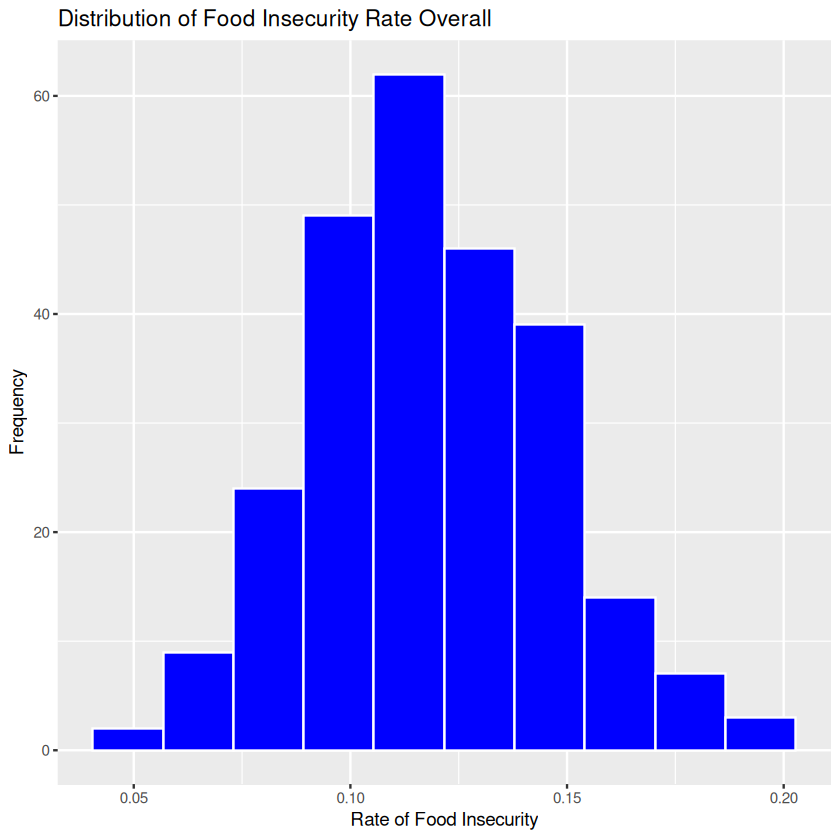

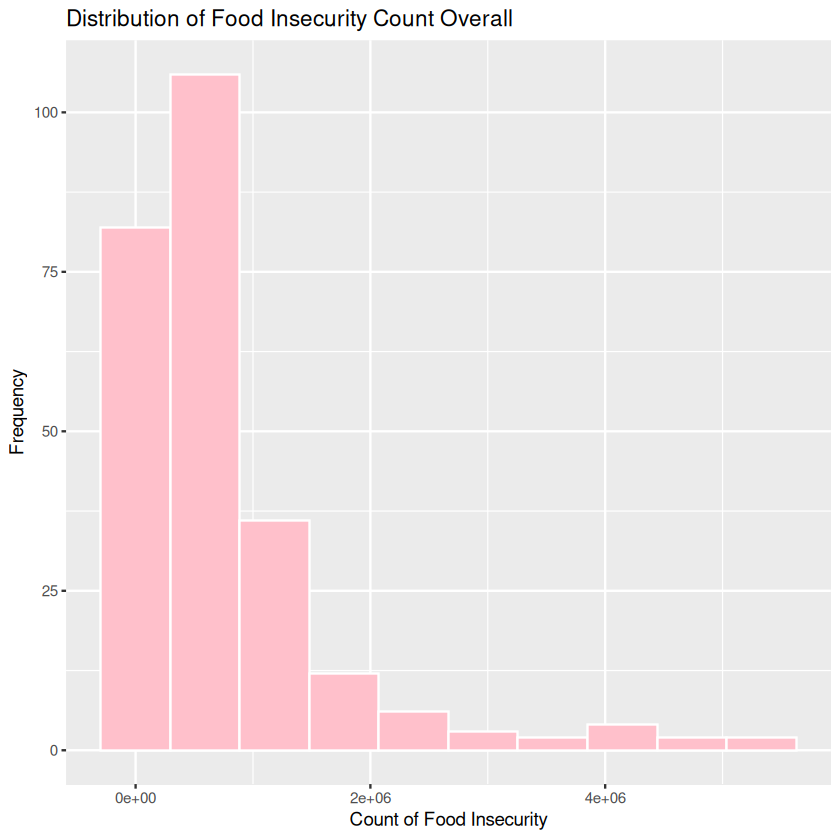

In [57]:
# Let's try making a plot. 
# We'll try making a histogram where the X-axis shows the rate of food insecurity and the Y-axis shows the frequency that that rate occurs across states
histogram_rate <- ggplot(mmg_state_clean, aes(x = FI_rate_overall)) +
                  geom_histogram(bins = 10, fill = 'blue', color = 'white') +
                  labs(title = 'Distribution of Food Insecurity Rate Overall',
                       x = 'Rate of Food Insecurity',
                       y = 'Frequency')

histogram_rate

histogram_count <- ggplot(mmg_state_clean, aes(x = FI_number_total)) +
                   geom_histogram(bins = 10, fill = 'pink', color = 'white') +
                   labs(title = 'Distribution of Food Insecurity Count Overall',
                        x = 'Count of Food Insecurity',
                        y = 'Frequency')
histogram_count

# Looking at both histograms, we probably want to work from here on out with rates rather than with counts. The count histogram is highly right skewed, probably because some states are much bigger than others. 